In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
df = pd.read_csv('50_Startups.csv', sep=',')

print("--- Sütun İsimleri ---")
print(df.columns.tolist())

print("\n--- İlk 5 Satır (Düzgün Format) ---")
print(df.head())

--- Sütun İsimleri ---
['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']

--- İlk 5 Satır (Düzgün Format) ---
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


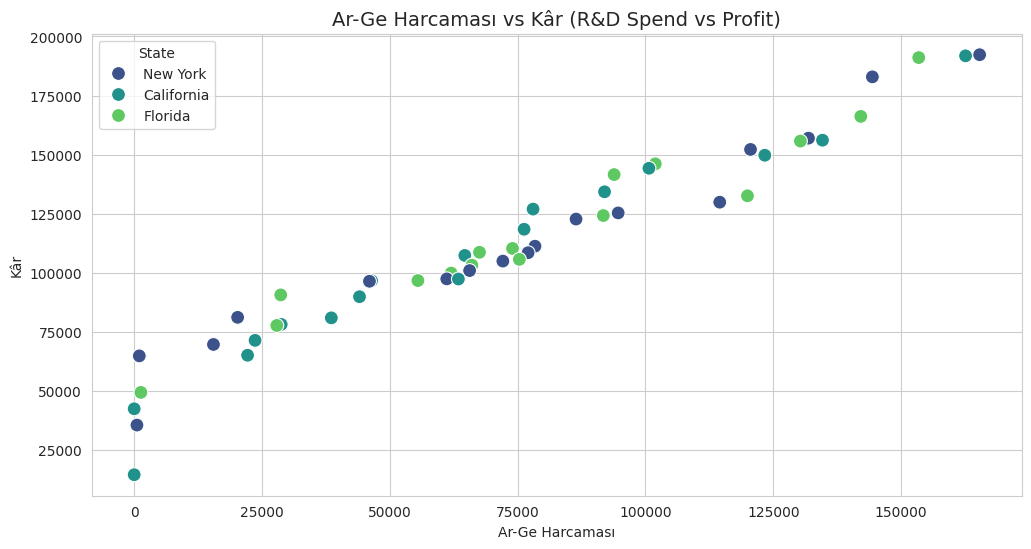

In [12]:
#1.SORU

import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.figure()
sns.scatterplot(x='R&D Spend', y='Profit', data=df, hue='State', s=100, palette='viridis')
plt.title('Ar-Ge Harcaması vs Kâr (R&D Spend vs Profit)', fontsize=14)
plt.xlabel('Ar-Ge Harcaması')
plt.ylabel('Kâr')
plt.show()

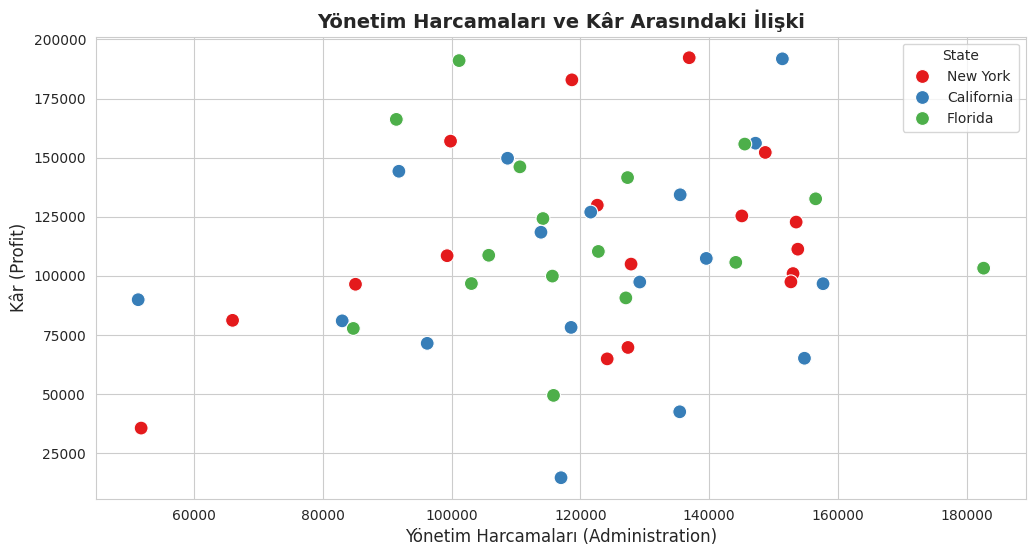

In [16]:
# --- 2. GÖREV: Yönetim Harcamaları vs Kâr (Scatter Plot) ---
sns.scatterplot(
    x='Administration',
    y='Profit',
    data=df,
    hue='State',
    s=100,
    palette='Set1',
    )
plt.title('Yönetim Harcamaları ve Kâr Arasındaki İlişki', fontsize=14, fontweight='bold')
plt.xlabel('Yönetim Harcamaları (Administration)', fontsize=12)
plt.ylabel('Kâr (Profit)', fontsize=12)
plt.show()

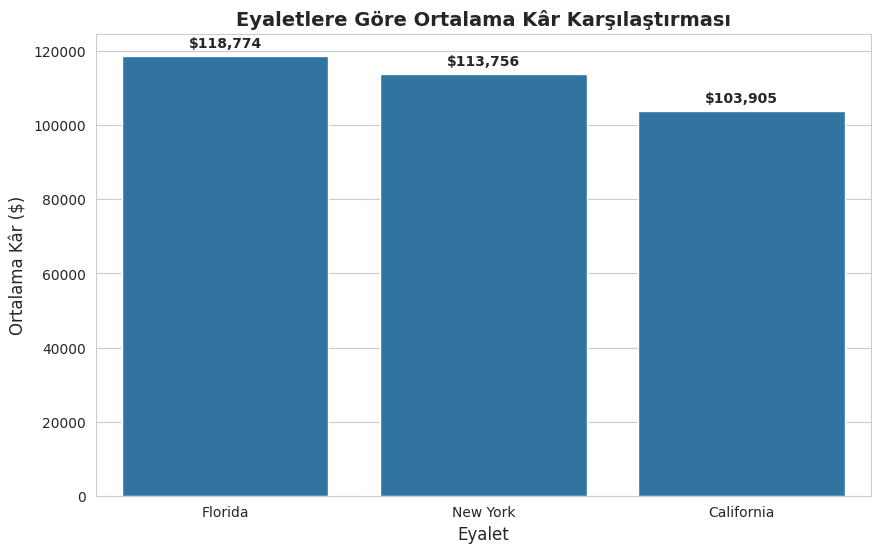

In [19]:
#3.SORU
# Her eyaletin ortalama kârını hesaplayalım
avg_profit = df.groupby('State')['Profit'].mean().reset_index()

# Kâr miktarına göre sıralayalım (Görsel olarak daha okunaklı olur)
avg_profit = avg_profit.sort_values(by='Profit', ascending=False)

# 3. Grafik Ayarları
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
 #Eyaletlere Göre Ortalama Kâr (Bar Chart) ---
barplot = sns.barplot(
    x='State',
    y='Profit',
    data=avg_profit,
)

# Başlık ve Etiketler
plt.title('Eyaletlere Göre Ortalama Kâr Karşılaştırması', fontsize=14, fontweight='bold')
plt.xlabel('Eyalet', fontsize=12)
plt.ylabel('Ortalama Kâr ($)', fontsize=12)

# Çubukların üzerine tam rakamları yazdıralım (Okuması kolay olsun)
for p in barplot.patches:
    barplot.annotate(f'${p.get_height():,.0f}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points',
                     fontweight='bold')

# Grafiği Göster
plt.show()

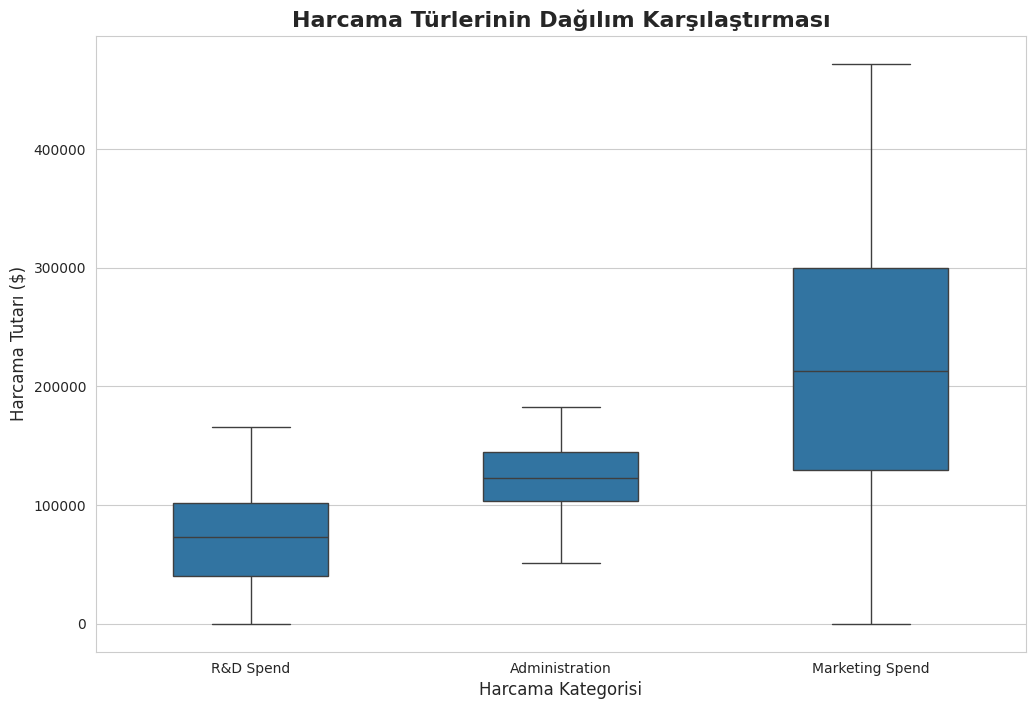

In [23]:
#4.SORU
# Veriyi Hazırlama
# Bu yüzden 'melt' fonksiyonu ile veriyi 'Harcama Tipi' ve 'Tutar' formatına çeviriyoruz.
melted_df = df.melt(value_vars=['R&D Spend', 'Administration', 'Marketing Spend'],
                    var_name='Harcama Tipi',
                    value_name='Tutar')

# 3. Grafik Ayarları
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))

# --- 4. GÖREV: Harcama Türlerinin Karşılaştırması (Boxplot) ---
sns.boxplot(
    x='Harcama Tipi',
    y='Tutar',
    data=melted_df,
    width=0.5
)
plt.title('Harcama Türlerinin Dağılım Karşılaştırması', fontsize=16, fontweight='bold')
plt.xlabel('Harcama Kategorisi', fontsize=12)
plt.ylabel('Harcama Tutarı ($)', fontsize=12)
plt.show()